# 2110203 Computer Engineering Mathematics II 
## Lecture 1 : Signal Processing
## Author : 6730084521 Chatrphol Ovanonchai

In [2]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
import IPython.display as ipd
import os
from scipy import signal,fftpack
from skimage.io import imread
import cv2

## Problem 1
Sketch the following signals
1.
$x(t) = \sin \left (\frac{\pi}{4}t + 20^\circ \right)$


2.
$x(t) = \begin{cases}t+2 , t \leq -2 \\ 0 , -2 \leq t \leq 2\\ t-2 , t \geq 2 \end{cases}$

3.
$x(t) = 2e^{-t}, 0 \leq t < 1$ and $ x(t+1) = x(t) $ for all $t$

4.
$x(t) = u(t) + 5u(t-1) -2u(t-2)$

5.
$x(t) = r(t) - r(t-1) - u(t-2)$




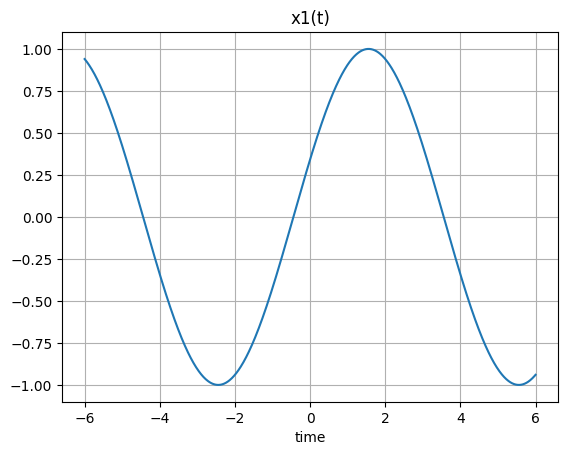

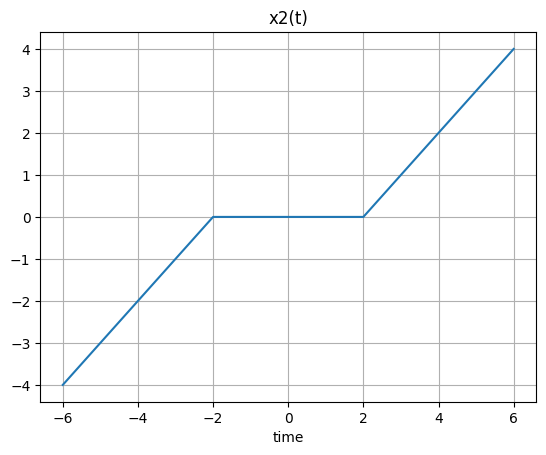

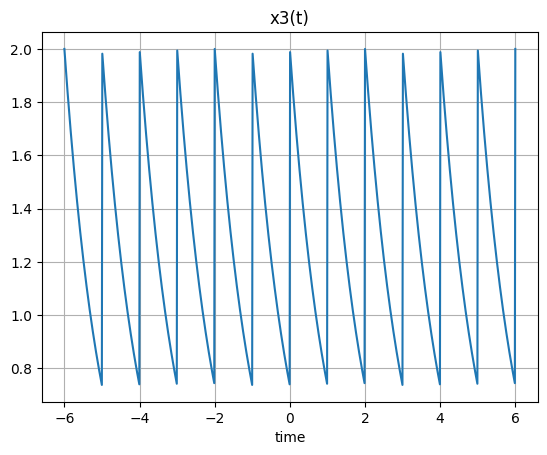

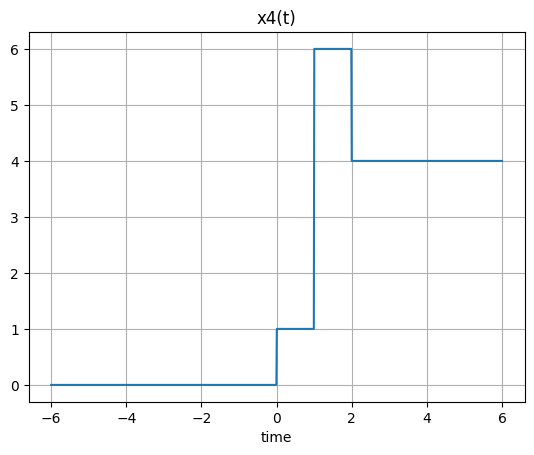

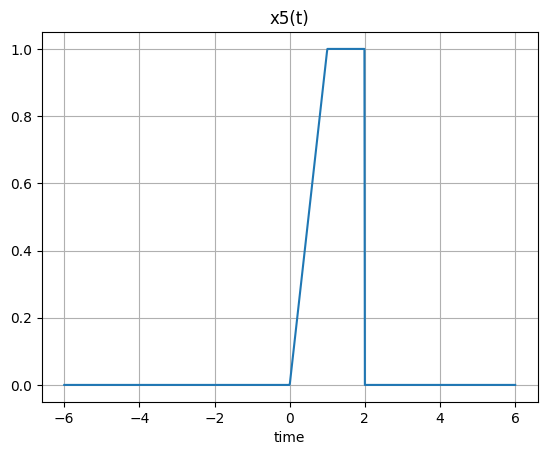

In [3]:
## define function for each task
def x1(time) : 
    return np.sin( np.pi / 4 * time + (20 / 180 * np.pi) )

def x2(time) : 
    ## note : we cant use normal if-else for checking range
    ## so using "np.select()" is safer , will select value matched in another array
    return np.select( [time < -2 , (-2 <= time) & (time <= 2), time > 2] , [time + 2 , 0 , time - 2] )
    
def x3(time) : 
    return 2 * np.e ** -( np.mod(time , 1) ) # time % 1 bcz it will come back to e^1 everytime

def x4(time) : # np.heaviside used for step function u(t) , r(t) = t * u(t)  
    ## note : np.heaviside(x , val) = check "x" condition which gives "val" on x == 0
    return 1 * np.heaviside(time , 1) + \
        5 * (np.heaviside(time-1 , 1)) - \
        2 * (np.heaviside(time-2 , 1))

def x5(time) : 
    ## note : r(t) = t * u(t) 
    return   time * (np.heaviside(time , 1)) - \
            (time-1) * (np.heaviside(time-1 , 1)) - \
            ( np.heaviside(time-2 , 1) )
            
## Plot graph 
time = np.linspace(-6 , 6 , 1000) # time is now array

plt.figure() 
plt.plot(time , x1(time)) # plot(x,y)
plt.title("x1(t)") ; plt.xlabel("time") ; plt.grid(True) ; plt.show()

plt.figure() 
plt.plot(time , x2(time)) # plot(x,y)
plt.title("x2(t)") ; plt.xlabel("time") ; plt.grid(True) ; plt.show()

plt.figure() 
plt.plot(time , x3(time)) # plot(x,y)
plt.title("x3(t)") ; plt.xlabel("time") ; plt.grid(True) ;  plt.show()

plt.figure() 
plt.plot(time , x4(time)) # plot(x,y)
plt.title("x4(t)") ; plt.xlabel("time") ; plt.grid(True) ;  plt.show()

plt.figure() 
plt.plot(time , x5(time)) # plot(x,y)
plt.title("x5(t)") ; plt.xlabel("time") ; plt.grid(True) ;  plt.show()

## subplots can help

## Problem 2
Determine whether each of following signals is periodic, and if so, find its period.

1.$x_4(t) = \sin \left( \frac{\pi}{3}t \right) + \cos \left( \frac{8\pi}{3}t \right)$

2.$x_5(t) = \exp \left  (j\frac{7\pi}{6}t \right) +  \exp \left( j\frac{5\pi}{6}t \right) $

3.$x_6(t) = \exp \left( j\frac{7\pi}{6}t \right) +  \exp \left(\frac{5\pi}{6}t \right) $


In [4]:
## Task 1 : check periodic with sympy 
from sympy import S, simplify, lcm, pi  ## note that , we should use sympy "pi" for calculation

## Note : using sympy tools ("S" for sympify , "simplify" for making rational)

# Step 1 : calculate angular frequency
w1 = pi / 3 # make 2 as sympi to not dividing number
w2 = S(8) * pi / 3 

# Step 2 : make rational and check if periodic with w1 / w2 (same as T2 / T1 as k/l)
f_ratio = simplify(w1 / w2)
is_x4_periodic = f_ratio.is_rational # if not rational , will not be periodic (ex 3/2pi)

if (is_x4_periodic == True) : 
    # find period of each graph
    T1 = (2 * pi) / (w1) ; T2 = (2 * pi) / (w2)
    T_fund = lcm(T1,T2) # fundamental period = Tz
    print(f"Periodic of x1(t) is {T_fund} seconds")
    
else : 
    print("This graph is not periodic")

Periodic of x1(t) is 6 seconds


In [5]:
## Task 2 : check periodic with sympy 
from sympy import S, simplify, lcm, pi  ## note that , we should use sympy "pi" for calculation

## Note : using sympy tools ("S" for sympify , "simplify" for making rational)

# Step 1 : calculate angular frequency
w1 = S(7) * pi / 6 # make 2 as sympi to not dividing number
w2 = S(5) * pi / 6

# Step 2 : make rational and check if periodic with w1 / w2 (same as T2 / T1 as k/l)
f_ratio = simplify(w1 / w2)
is_x5_periodic = f_ratio.is_rational # if not rational , will not be periodic (ex 3/2pi)

if (is_x5_periodic == True) : 
    # find period of each graph
    T1 = (2 * pi) / (w1) ; T2 = (2 * pi) / (w2)
    T_fund = lcm(T1,T2) # fundamental period = Tz
    print(f"Periodic of x1(t) is {T_fund} seconds")
    
else : 
    print("This graph is not periodic")

Periodic of x1(t) is 12 seconds


In [6]:
## Task 3 : check periodic with sympy 
## no need to use , we can check from second signal ( e^(5pi/6 t) )
## second signal shows it wont be periodic 

## So the overall signal won't be periodic for sure !!!

## Problem 3
Determine whether the following signals are power or energy signals or neither. Justify your answers

1. $x_7(t) = A\sin( t ), -\infty < t < \infty$
2. $x_8(t) = A(u(t-a) - u(t+a)), \, a>0 $
4. $x_9(t) = \exp(-at)u(t), \,  a>0 $
7. $x_{10}(t) = A\exp(bt)u(t), \, b>0$



In [7]:
import sympy as sp

## define symbol for integration
t = sp.symbols("t", real=True) ## real variable
T, A, a, b = sp.symbols("T A a b", positive=True)

## note : integrate in form : sp.integrate(f(x), (x, lower, upper))
# x7_t = A * sp.sin(t)
# x8_t = A * (sp.Heaviside(t - a) - sp.Heaviside(t + a))
# x9_t = sp.exp(-a * t) * sp.Heaviside(t)
# x10_t = A * sp.exp(b * t) * sp.Heaviside(t)


# x7(t) = A sin(t)
energy_1 = sp.integrate(
    (A * sp.sin(t)) ** 2,
    (t, -sp.oo, sp.oo) 
)

power_1 = sp.limit(
    sp.integrate(
        (A * sp.sin(t)) ** 2,
        (t, -T, T) # integrate -T to T 
    ) / (2 * T),
    T,
    sp.oo # lim(T -> inf)
)

print(
    f"Energy of x7(t) = {energy_1}, "
    f"Power of x7(t) = {power_1}"
)


# x8(t) = A[u(t-a) - u(t+a)]
# สัญญาณมีค่า -A ตั้งแต่ -a ถึง a
energy_2 = sp.integrate(
    A ** 2,
    (t, -a, a) 
)

power_2 = sp.limit(
    energy_2 / (2 * T),
    T,
    sp.oo
)

print(
    f"Energy of x8(t) = {energy_2}, "
    f"Power of x8(t) = {power_2}"
)


# x9(t) = exp(-at)u(t)
# u(t) ถูกแทนด้วยขอบเขตเริ่มต้นที่ 0
energy_3 = sp.integrate(
    sp.exp(-2 * a * t),
    (t, 0, sp.oo)
)

power_3 = sp.limit(
    sp.integrate(
        sp.exp(-2 * a * t),
        (t, 0, T)
    ) / (2 * T),
    T,
    sp.oo
)

print(
    f"Energy of x9(t) = {energy_3}, "
    f"Power of x9(t) = {power_3}"
)


# x10(t) = A exp(bt)u(t)
# u(t) ถูกแทนด้วยขอบเขตเริ่มต้นที่ 0
energy_4 = sp.integrate(
    A ** 2 * sp.exp(2 * b * t),
    (t, 0, sp.oo)
)

power_4 = sp.limit(
    sp.integrate(
        A ** 2 * sp.exp(2 * b * t),
        (t, 0, T)
    ) / (2 * T),
    T,
    sp.oo
)

print(
    f"Energy of x10(t) = {energy_4}, "
    f"Power of x10(t) = {power_4}"
)

Energy of x7(t) = oo, Power of x7(t) = A**2/2
Energy of x8(t) = 2*A**2*a, Power of x8(t) = 0
Energy of x9(t) = 1/(2*a), Power of x9(t) = 0
Energy of x10(t) = oo, Power of x10(t) = oo


## Problem 4
For the discrete time signal x[n] shown in Figure below, sketch each of the following

1. $x[2-n] $
2. $x[3n-4] $
3. $x\left[ \frac{2}{3}n+1 \right]  $
4. $x\left[-\frac{n+8}{4} \right] $
5. $x[n^3] $
8. $x[2-n] +x[3n-4] $

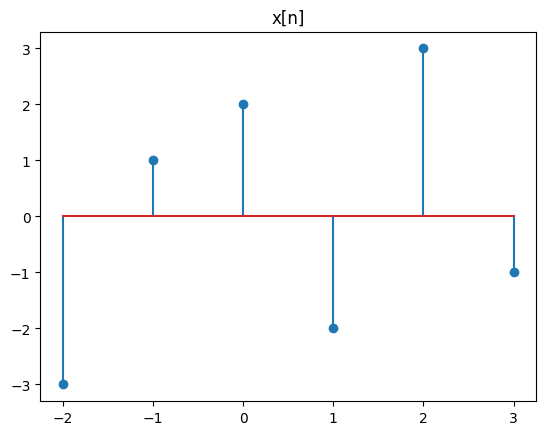

In [8]:
# x[n]
t = np.arange(-2,4)
x_t = np.array([-3,1,2,-2,3,-1])
plt.stem(t, x_t)
plt.title('x[n]')
plt.show()

## Problem 5
Determine whether each of following signals is periodic, and if so, find its period.

1.
$x[n] = \sin \left( \frac{\pi n}{4} + \frac{\pi}{8}\right)$

2.
$x[n] = \sin \left( \frac{3\pi n}{4}\right) + \sin\left( \frac{\pi}{3}n\right)$

3.
$x[n] = \sin \left( \frac{3\pi n}{4}\right)\sin\left( \frac{\pi}{3}n\right)$

4.
$x[n] = \exp \left( \frac{6\pi}{5}n \right)$

5.
$x[n] = \exp \left( j\frac{5\pi}{6}n \right)$

6.
$x[n] =  \sum_{m=-\infty}^{\infty} \left[ \delta[n-2m] + 2\delta[n-3m] \right]$

<!-- 1.
$x[n] = \sin \left( \frac{3\pi n}{4}\right) + \cos \left( \frac{\pi}{3} n \right)$ -->

 ## Problem 6

 [python] Signal transformations :
 Study the sawtooth function in the figure below. Apply reflection, scaling, shifting operations to the signal and plot the transformed signals compared with the original sawtooth signal.  


In [9]:
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt
%matplotlib inline

In [10]:
# t = np.linspace(-1, 1, 500)
# plt.plot(t, signal.sawtooth(2 * np.pi * 5 * t))
# plt.show()

In [11]:
# t = np.linspace(-1, 1, 500)
# plt.plot(t, signal.sawtooth(2 * np.pi * 5 * t))

# scaling factor = 3 and 1/3
## TODO : writing code for time scaling

In [12]:
# t = np.linspace(-1, 1, 500)
# plt.plot(t, signal.sawtooth(2 * np.pi * 5 * t))

# shifting t to the left and right 0.05 units

## TODO : writing code for time shifting

In [13]:
# plt.plot(t, signal.sawtooth(2 * np.pi * 5 * t))

## TODO : writing code for time Reflection


  ## Problem 7
 [python] Elementary signals: study  the ramp signal plotted in the example below. \\
TODO : plot these signals

1.   Unit step function
2.   Unit impulse function



In [14]:
# t = np.linspace(-1, 1, 500)
# ramp_t = t.copy()
# ramp_t[ramp_t < 0 ] = 0
# plt.plot(t, ramp_t)
# plt.show()

In [15]:
## TODO : writing code for plotting unit step function

In [16]:
## TODO : writing code for plotting unit impulse function

## Problem 8
Express the signal that shown in Figure below using Unit-ramp functions



<a href="https://ibb.co/pXt8t2Y"><img src="https://i.ibb.co/DKxyx40/Screen-Shot-2564-08-11-at-15-16-52.png" alt="Screen-Shot-2564-08-11-at-15-16-52" border="0"></a>



## Problem 9

Evaluate the following integrals

1. $\int_{-\infty}^{\infty} \left( \frac{2}{3}t-\frac{3}{2} \right) \delta(t-1) \,dt$

1. $\int_{-\infty}^{\infty} (t-1) \delta \left(\frac{2}{3}t- \frac{3}{2} \right) \,dt$

1. $\int_{-3}^{-2} \left[ e^{(-t+1)} + \sin \left( \frac{2\pi t}{3} \right) \right] \delta \left(t- \frac{3}{2} \right) \,dt$

1. $\int_{-3}^{2} \left[ e^{(-t+1)} + \sin \left( \frac{2\pi t}{3} \right) \right] \delta \left(t- \frac{3}{2} \right) \,dt$